<a href="https://colab.research.google.com/github/fajar22222/Prediksi_Volume_Kendaraan-SDG-11/blob/main/Tingkat__Kepadatan__Lalu__Lintas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Klasifikasi Tingkat Kepadatan Lalu Lintas Menggunakan Decision Tree Classifier untuk Mendukung - SDGS 11**

## Klasifikasi Tingkat Kepadatan Lalu Lintas menggunakan Decision Tree Classifier

- **Problem:** Bagaimana mengklasifikasikan tingkat kepadatan lalu lintas (Rendah, Sedang, dan Tinggi) berdasarkan kondisi waktu dan cuaca agar dapat membantu memahami pola kepadatan lalu lintas di kawasan perkotaan?
- **Topik SDGs:** SDGs 11 - Sustainable Cities and Communities, khususnya pemanfaatan teknologi untuk mendukung transportasi dan pengelolaan kawasan perkotaan yang lebih berkelanjutan.
- **Tujuan Project:** Membangun model Machine Learning menggunakan Decision Tree Classifier untuk mengklasifikasikan tingkat kepadatan lalu lintas berdasarkan data waktu dan kondisi cuaca.

##1 Memuat Data

Dataset: **Metro Interstate Traffic Volume**

Sumber: UCI Machine Learning Repository  

Pada tahap ini dataset dimuat menggunakan Pandas.

Tujuan tahap ini adalah memastikan dataset berhasil dibaca serta mengetahui struktur, ukuran, tipe data, dan karakteristik awal data.

In [198]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Metro_Interstate_Traffic_Volume.csv")



print("Data berhasil dimuat!")

Data berhasil dimuat!


### Melihat Data Awal

`head()` digunakan untuk melihat beberapa baris pertama dataset sehingga struktur dan isi data dapat dikenali.

In [199]:
#tampilkan 5 data pertama:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,10/2/2012 9:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,10/2/2012 10:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,10/2/2012 11:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,10/2/2012 12:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,10/2/2012 13:00,4918


### Mengecek Ukuran Dataset

`shape` digunakan untuk mengetahui jumlah baris dan kolom dalam dataset.

In [200]:
#Cek ukuran dataset
df.shape

(48204, 9)

### Mengecek Struktur Data

`info()` digunakan untuk mengetahui nama kolom, tipe data, dan jumlah data pada setiap kolom.

In [201]:
#Cek struktur data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


### Statistik Deskriptif

`describe()` digunakan untuk melihat statistik dasar pada data numerik, seperti jumlah data, rata-rata, nilai minimum, maksimum, dan kuartil.

In [202]:
#Cek statistik awal
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


##2  Preprocessing Data
Pada tahap ini dilakukan persiapan data sebelum digunakan dalam proses Machine Learning.

Proses yang dilakukan meliputi pengecekan missing value, pengecekan data duplikat, pembersihan data, serta persiapan data awal.

In [203]:
# Mengecek jumlah data kosong
df.isnull().sum()

,0
holiday,48143
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
traffic_volume,0


In [204]:
# Mengecek jumlah data duplikat
df.duplicated().sum()

np.int64(17)

In [205]:
# melihat informasi data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [206]:
# Mengubah date_time menjadi format datetime
df['date_time'] = pd.to_datetime(df['date_time'])

# Melihat hasilnya
df[['date_time']].head()

,date_time
0,2012-10-02 09:00:00
1,2012-10-02 10:00:00
2,2012-10-02 11:00:00
3,2012-10-02 12:00:00
4,2012-10-02 13:00:00


In [207]:
# Membuat fitur waktu
df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day
df['month'] = df['date_time'].dt.month
df['day_of_week'] = df['date_time'].dt.dayofweek
df['year'] = df['date_time'].dt.year

# Melihat hasil
df[['date_time', 'hour', 'day', 'month', 'day_of_week', 'year']].head()

,date_time,hour,day,month,day_of_week,year
0,2012-10-02 09:00:00,9,2,10,1,2012
1,2012-10-02 10:00:00,10,2,10,1,2012
2,2012-10-02 11:00:00,11,2,10,1,2012
3,2012-10-02 12:00:00,12,2,10,1,2012
4,2012-10-02 13:00:00,13,2,10,1,2012


In [208]:
# Mengubah suhu menjadi celcius
df['temp_c'] = df['temp'] - 273.15

df[['temp', 'temp_c']].head()

,temp,temp_c
0,288.28,15.13
1,289.36,16.21
2,289.58,16.43
3,290.13,16.98
4,291.14,17.99


In [209]:
#Menentukan fitur yang digunakan
features = [
    'hour',
    'day',
    'month',
    'day_of_week',
    'year',
    'temp_c',
    'rain_1h',
    'snow_1h',
    'clouds_all',
    'weather_main',
    'holiday'
]

In [210]:
# Melihat batas persentil
q1 = df['traffic_volume'].quantile(0.33)
q2 = df['traffic_volume'].quantile(0.66)

print("Batas Rendah :", q1)
print("Batas Sedang :", q2)

def kategori_traffic(volume):
    if volume <= q1:
        return 'Rendah'
    elif volume <= q2:
        return 'Sedang'
    else:
        return 'Tinggi'

df['Traffic_Level'] = df['traffic_volume'].apply(kategori_traffic)

Batas Rendah : 2157.9900000000016
Batas Sedang : 4546.0


In [211]:
df[['traffic_volume', 'Traffic_Level']].head(10)

,traffic_volume,Traffic_Level
0,5545,Tinggi
1,4516,Sedang
2,4767,Tinggi
3,5026,Tinggi
4,4918,Tinggi
5,5181,Tinggi
6,5584,Tinggi
7,6015,Tinggi
8,5791,Tinggi
9,4770,Tinggi


In [212]:
df['Traffic_Level'].value_counts()

,count
Traffic_Level,
Tinggi,16379
Sedang,15918
Rendah,15907


In [213]:
df.head()

print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Jumlah baris : 48204
Jumlah kolom : 16


##Cleaning Data

In [214]:
# Menghapus data duplikat
df = df.drop_duplicates()

print("Jumlah data setelah menghapus duplikat:", len(df))

Jumlah data setelah menghapus duplikat: 48187


In [215]:
# Mengubah holiday menjadi fitur biner
# 0 = bukan hari libur
# 1 = hari libur
df['holiday'] = df['holiday'].fillna(0)
df['holiday'] = (df['holiday'].astype(str).str.strip() != '0').astype(int)


###mengetahui apakah terdapat data kosong pada setiap kolom.


In [216]:
print("Missing value:")
print(df.isnull().sum())

print("\nJumlah data:")
print(df.shape)

Missing value:
holiday                0
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
date_time              0
traffic_volume         0
hour                   0
day                    0
month                  0
day_of_week            0
year                   0
temp_c                 0
Traffic_Level          0
dtype: int64

Jumlah data:
(48187, 16)


## 3 Transformasi Data & Feature Engineering
Pada tahap ini data diubah menjadi fitur yang lebih sesuai untuk digunakan dalam model.

Informasi tanggal dan waktu dari `date_time` dipecah menjadi beberapa fitur seperti jam, hari, bulan, hari dalam minggu, dan tahun.

Selain itu, suhu dari Kelvin diubah menjadi Celsius.

In [217]:
# Mengubah kolom date_time menjadi format datetime
df['date_time'] = pd.to_datetime(df['date_time'])

In [218]:
# Membuat fitur berdasarkan waktu
df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day
df['month'] = df['date_time'].dt.month
df['day_of_week'] = df['date_time'].dt.dayofweek
df['year'] = df['date_time'].dt.year

In [219]:
# Mengubah suhu dari Kelvin menjadi Celsius
df['temp_c'] = df['temp'] - 273.15


In [220]:
# Menampilkan hasil transformasi
df[['date_time', 'hour', 'day', 'month',
    'day_of_week', 'year', 'temp_c']].head()

,date_time,hour,day,month,day_of_week,year,temp_c
0,2012-10-02 09:00:00,9,2,10,1,2012,15.13
1,2012-10-02 10:00:00,10,2,10,1,2012,16.21
2,2012-10-02 11:00:00,11,2,10,1,2012,16.43
3,2012-10-02 12:00:00,12,2,10,1,2012,16.98
4,2012-10-02 13:00:00,13,2,10,1,2012,17.99


## 4 Membuat Target / Label Traffic_Level
Pada tahap ini nilai `traffic_volume` diubah menjadi tiga kategori tingkat kepadatan lalu lintas:

- Rendah
- Sedang
- Tinggi

Kolom `traffic_volume` digunakan untuk membentuk target, tetapi tidak digunakan sebagai fitur X agar tidak terjadi target leakage.

In [221]:
# Menentukan batas kategori berdasarkan quantile
q1 = df['traffic_volume'].quantile(0.33)
q2 = df['traffic_volume'].quantile(0.66)

print("Batas Rendah :", q1)
print("Batas Sedang :", q2)

Batas Rendah : 2157.0
Batas Sedang : 4546.0


In [222]:
# Membuat kategori tingkat kepadatan lalu lintas
def kategori_traffic(volume):
    if volume <= q1:
        return 'Rendah'
    elif volume <= q2:
        return 'Sedang'
    else:
        return 'Tinggi'

df['Traffic_Level'] = df['traffic_volume'].apply(kategori_traffic)

In [223]:
# Melihat hubungan traffic_volume dengan Traffic_Level
df[['traffic_volume', 'Traffic_Level']].head(10)

,traffic_volume,Traffic_Level
0,5545,Tinggi
1,4516,Sedang
2,4767,Tinggi
3,5026,Tinggi
4,4918,Tinggi
5,5181,Tinggi
6,5584,Tinggi
7,6015,Tinggi
8,5791,Tinggi
9,4770,Tinggi


In [224]:
# Melihat jumlah masing-masing kategori
df['Traffic_Level'].value_counts()

,count
Traffic_Level,
Tinggi,16371
Sedang,15912
Rendah,15904


##5 Encoding Data

Pada tahap ini data kategorikal pada `weather_main` diubah menjadi bentuk numerik menggunakan metode One-Hot Encoding agar dapat digunakan oleh model Decision Tree.

In [225]:
# Melihat hasil encoding
df['holiday'].value_counts()

,count
holiday,
0,48126
1,61


In [226]:
# Mengecek nilai unik pada kolom holiday
print(df['holiday'].unique())

[0 1]


In [227]:
# Mengecek jumlah masing-masing nilai
print(df['holiday'].value_counts(dropna=False))

holiday
0    48126
1       61
Name: count, dtype: int64


In [228]:
# Mengecek kategori cuaca
print(df['weather_main'].unique())

# Melihat jumlah masing-masing kategori
print(df['weather_main'].value_counts())

['Clouds' 'Clear' 'Rain' 'Drizzle' 'Mist' 'Haze' 'Fog' 'Thunderstorm'
 'Snow' 'Squall' 'Smoke']
weather_main
Clouds          15158
Clear           13384
Mist             5949
Rain             5672
Snow             2875
Drizzle          1820
Haze             1360
Thunderstorm     1033
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64


In [229]:
# Melakukan One-Hot Encoding pada weather_main
df = pd.get_dummies(
    df,
    columns=['weather_main'],
    prefix='weather',
    dtype=int
)

# Melihat hasil encoding
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_description,date_time,traffic_volume,hour,day,...,weather_Clouds,weather_Drizzle,weather_Fog,weather_Haze,weather_Mist,weather_Rain,weather_Smoke,weather_Snow,weather_Squall,weather_Thunderstorm
0,0,288.28,0.0,0.0,40,scattered clouds,2012-10-02 09:00:00,5545,9,2,...,1,0,0,0,0,0,0,0,0,0
1,0,289.36,0.0,0.0,75,broken clouds,2012-10-02 10:00:00,4516,10,2,...,1,0,0,0,0,0,0,0,0,0
2,0,289.58,0.0,0.0,90,overcast clouds,2012-10-02 11:00:00,4767,11,2,...,1,0,0,0,0,0,0,0,0,0
3,0,290.13,0.0,0.0,90,overcast clouds,2012-10-02 12:00:00,5026,12,2,...,1,0,0,0,0,0,0,0,0,0
4,0,291.14,0.0,0.0,75,broken clouds,2012-10-02 13:00:00,4918,13,2,...,1,0,0,0,0,0,0,0,0,0


Melihat Kolom Setelah Encoding

In [230]:
# Mengecek nama kolom setelah encoding
print(df.columns.tolist())

['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_description', 'date_time', 'traffic_volume', 'hour', 'day', 'month', 'day_of_week', 'year', 'temp_c', 'Traffic_Level', 'weather_Clear', 'weather_Clouds', 'weather_Drizzle', 'weather_Fog', 'weather_Haze', 'weather_Mist', 'weather_Rain', 'weather_Smoke', 'weather_Snow', 'weather_Squall', 'weather_Thunderstorm']


In [231]:
# Mengecek ukuran data setelah encoding
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Jumlah baris : 48187
Jumlah kolom : 26


## 6 Menentukan X dan Y

`X` merupakan fitur atau data input yang digunakan oleh model.

`Y` merupakan target yang akan diprediksi, yaitu `Traffic_Level`.

Kolom `traffic_volume` tidak dimasukkan ke dalam X karena digunakan untuk membentuk target.

In [232]:
# Menentukan fitur yang digunakan sebagai input model
X = df[
    [
        'holiday',
        'temp_c',
        'rain_1h',
        'snow_1h',
        'clouds_all',
        'hour',
        'day',
        'month',
        'day_of_week',
        'year',
        'weather_Clear',
        'weather_Clouds',
        'weather_Drizzle',
        'weather_Fog',
        'weather_Haze',
        'weather_Mist',
        'weather_Rain',
        'weather_Smoke',
        'weather_Snow',
        'weather_Squall',
        'weather_Thunderstorm'
    ]
]

# Menentukan target yang akan diprediksi
y = df['Traffic_Level']

# Melihat bentuk X dan Y
print("Ukuran X :", X.shape)
print("Ukuran Y :", y.shape)

Ukuran X : (48187, 21)
Ukuran Y : (48187,)


## 7 — Train-Test Split

Dataset dibagi menjadi dua bagian:

- **Data Training** → digunakan untuk melatih model.
- **Data Testing** → digunakan untuk menguji kemampuan model.

Sebanyak 80% data digunakan untuk training dan 20% untuk testing.

In [233]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi data training dan data testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Melihat ukuran masing-masing data
print("Data Training :", X_train.shape)
print("Data Testing  :", X_test.shape)

Data Training : (38549, 21)
Data Testing  : (9638, 21)


## 8 — Pemodelan Decision Tree Classifier

Pada tahap ini model Decision Tree Classifier dibuat dan dilatih menggunakan data training.

In [234]:
from sklearn.tree import DecisionTreeClassifier

# Membuat model Decision Tree
model = DecisionTreeClassifier(
    random_state=42
)

# Melatih model menggunakan data training
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [235]:
# Melakukan prediksi pada data testing
y_pred = model.predict(X_test)

# Menampilkan beberapa hasil prediksi
print(y_pred[:10])

['Tinggi' 'Rendah' 'Sedang' 'Sedang' 'Sedang' 'Tinggi' 'Tinggi' 'Tinggi'
 'Rendah' 'Sedang']


##9 Evaluasi Model

Pada tahap ini performa model diukur menggunakan akurasi dan classification report.

In [236]:
from sklearn.metrics import accuracy_score, classification_report

# Menghitung akurasi
accuracy = accuracy_score(y_test, y_pred)

print("Akurasi Model :", accuracy)

# Menampilkan classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Akurasi Model : 0.9118074289271633

Classification Report:
              precision    recall  f1-score   support

      Rendah       0.95      0.95      0.95      3181
      Sedang       0.87      0.87      0.87      3183
      Tinggi       0.92      0.92      0.92      3274

    accuracy                           0.91      9638
   macro avg       0.91      0.91      0.91      9638
weighted avg       0.91      0.91      0.91      9638



## Confusion Matrix

Confusion Matrix digunakan untuk melihat jumlah prediksi yang benar dan salah pada setiap kategori tingkat kepadatan lalu lintas.

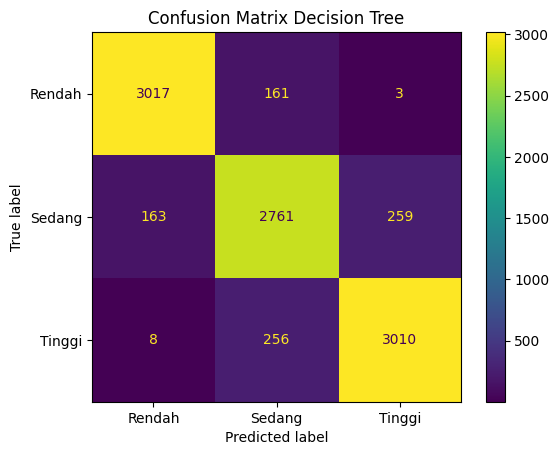

In [237]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Rendah', 'Sedang', 'Tinggi']
)

disp.plot()
plt.title('Confusion Matrix Decision Tree')
plt.show()

## Feature Importance
Berguna untuk mengetahui fitur apa yang paling banyak digunakan oleh Decision Tree dalam menentukan tingkat kepadatan lalu lintas.

In [238]:
import pandas as pd
import matplotlib.pyplot as plt

# Mengambil nilai feature importance
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
hour                    0.630248
day_of_week             0.147220
temp_c                  0.071312
day                     0.050348
month                   0.037515
year                    0.026970
clouds_all              0.015760
rain_1h                 0.007070
weather_Clouds          0.005266
weather_Clear           0.002756
weather_Mist            0.001165
weather_Rain            0.001160
weather_Snow            0.001063
weather_Haze            0.000901
weather_Fog             0.000536
snow_1h                 0.000323
weather_Drizzle         0.000170
weather_Thunderstorm    0.000145
weather_Smoke           0.000072
holiday                 0.000000
weather_Squall          0.000000
dtype: float64


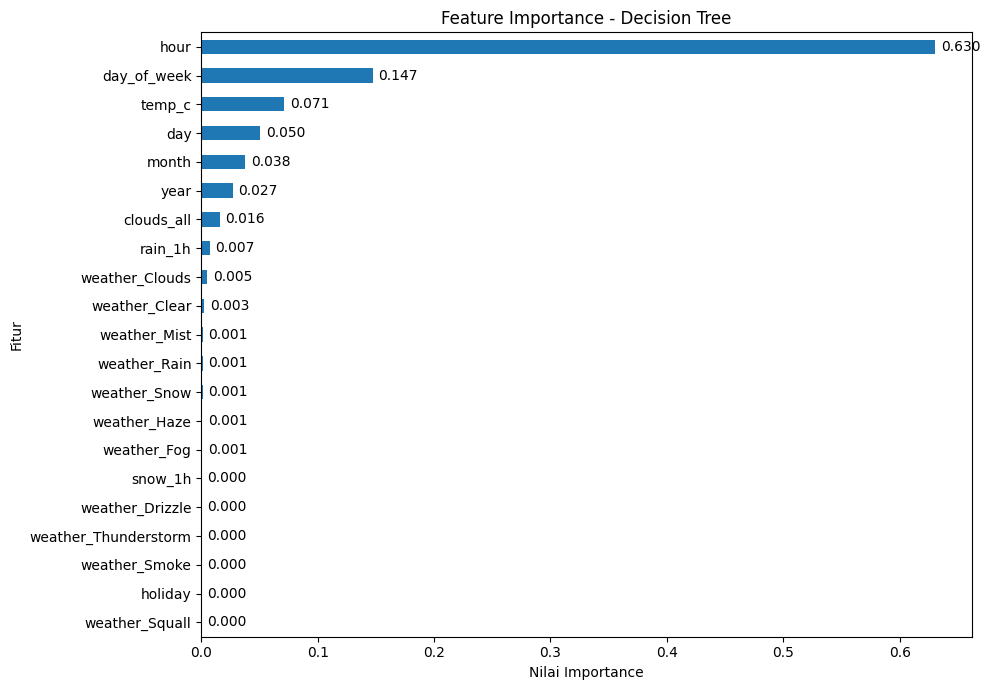

In [239]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

feature_importance.sort_values().plot(kind='barh')

plt.title('Feature Importance - Decision Tree')
plt.xlabel('Nilai Importance')
plt.ylabel('Fitur')

# Menampilkan nilai pada setiap batang
for i, value in enumerate(feature_importance.sort_values()):
    plt.text(value + 0.005, i, f'{value:.3f}', va='center')

plt.tight_layout()
plt.show()

## 10 Prediksi Data Baru
Prediksi Data Baru

Pada tahap ini model digunakan untuk melakukan klasifikasi terhadap data baru yang belum pernah digunakan saat training maupun testing.

In [240]:


#Menentukan tanggal yang ingin digunakan untuk melakukan prediksi
tanggal = pd.Timestamp('2026-10-5')

#prediksi data baru
data_baru = pd.DataFrame([{
    'holiday': 0,
    'temp_c': 27,
    'rain_1h': 0,
    'snow_1h': 0,
    'clouds_all': 40,
    'hour': 17,
    'day': tanggal.day,
    'month': tanggal.month,
    'day_of_week': tanggal.dayofweek,
    'year': tanggal.year,
    'weather_Clear': 1,
    'weather_Clouds': 0,
    'weather_Drizzle': 0,
    'weather_Fog': 0,
    'weather_Haze': 0,
    'weather_Mist': 0,
    'weather_Rain': 0,
    'weather_Smoke': 0,
    'weather_Snow': 0,
    'weather_Squall': 0,
    'weather_Thunderstorm': 0
}])

nama_hari = ['Senin', 'Selasa', 'Rabu', 'Kamis',
             'Jumat', 'Sabtu', 'Minggu']



# Melakukan prediksi
prediksi = model.predict(data_baru)

# Menampilkan informasi penting

print("=====||PREDIKSI TINGKAT LALU LINTAS||=====\n")

print(f"Jam              : {data_baru['hour'].iloc[0]}:00")
print(f"Suhu             : {data_baru['temp_c'].iloc[0]} °C")
print(f"Curah Hujan      : {data_baru['rain_1h'].iloc[0]} mm")
print(f"Salju            : {data_baru['snow_1h'].iloc[0]} mm")
print(f"Tutupan Awan     : {data_baru['clouds_all'].iloc[0]} %")
print("Hari              :", nama_hari[tanggal.dayofweek])
print(f"Bulan             : {data_baru['month'].iloc[0]}")
print(f"Tahun             : {data_baru['year'].iloc[0]}")

print("-" * 45)
print(f"HASIL PREDIKSI    : {prediksi[0]}")
print("=" * 45)

=====||PREDIKSI TINGKAT LALU LINTAS||=====

Jam              : 17:00
Suhu             : 27 °C
Curah Hujan      : 0 mm
Salju            : 0 mm
Tutupan Awan     : 40 %
Hari              : Senin
Bulan             : 10
Tahun             : 2026
---------------------------------------------
HASIL PREDIKSI    : Tinggi


## Kesimpulan

Project ini berhasil membangun model machine learning menggunakan Decision Tree Classifier untuk mengklasifikasikan tingkat kepadatan lalu lintas menjadi tiga kategori, yaitu Rendah, Sedang, dan Tinggi. Model menggunakan data volume lalu lintas dan kondisi lingkungan yang telah melalui tahap pembersihan, transformasi, encoding, dan pembagian data training dan testing.

Berdasarkan hasil pengujian, model Decision Tree Classifier berhasil mengklasifikasikan tingkat kepadatan lalu lintas ke dalam tiga kategori, yaitu Rendah, Sedang, dan Tinggi dengan akurasi sebesar 91,18%. Berdasarkan feature importance, fitur hour menjadi fitur yang paling berpengaruh terhadap keputusan model dengan nilai 0,630248. Pada pengujian data baru dengan jam 17:00, suhu 27°C, curah hujan 0 mm, salju 0 mm, dan tutupan awan 40%, model memprediksi tingkat lalu lintas berada pada kategori Tinggi.

Pada pengujian menggunakan data baru, model menghasilkan prediksi tingkat kepadatan lalu lintas Tinggi. Model ini dapat digunakan sebagai contoh penerapan AI untuk membantu klasifikasi kondisi lalu lintas, yang relevan dengan SDGs 11 (Sustainable Cities and Communities) dalam konteks pemanfaatan teknologi untuk mendukung pengelolaan kawasan perkotaan.